In [6]:
# load results 

import pandas as pd
import matplotlib.pyplot as plt

metrics_df = pd.read_csv("/Users/mariaworkman/fashion/fashion-neutrality/data/results/metrics_full_run.csv")

# keep only valid rows
metrics_df = metrics_df[metrics_df["ok"] == True]

In [7]:
# aggregate by year 

yearly = (
    metrics_df
    .groupby("year")
    .agg(
        mean_chroma=("mean_chroma", "mean"),
        neutral_share=("neutral_share", "mean"),
        count=("mean_chroma", "size")
    )
    .reset_index()
    .sort_values("year")
)

yearly.head()

,year,mean_chroma,neutral_share,count
0,2000,16.708127,0.699339,100
1,2001,16.130038,0.702347,100
2,2002,14.751548,0.741918,100
3,2003,14.293826,0.747077,100
4,2004,14.250137,0.774431,100


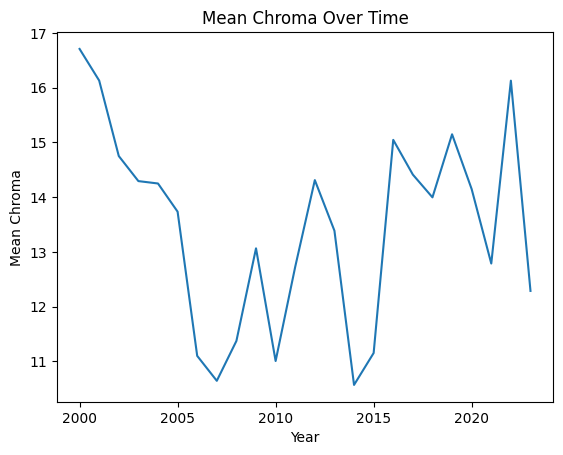

In [8]:
# plot mean chroma over years 

plt.figure()
plt.plot(yearly["year"], yearly["mean_chroma"])
plt.xlabel("Year")
plt.ylabel("Mean Chroma")
plt.title("Mean Chroma Over Time")
plt.show()


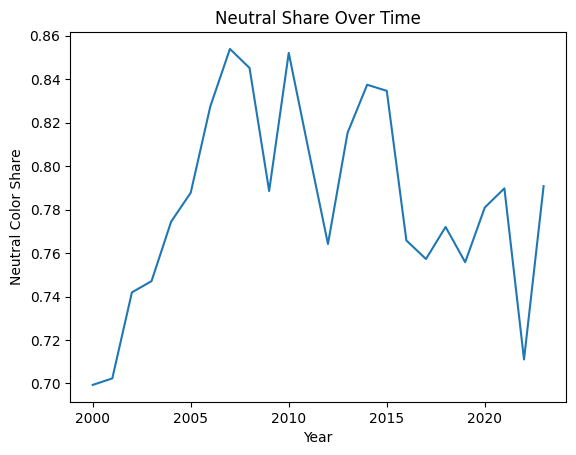

In [9]:
# plot neutral share over years (could be pretty messy, need to adjust cutoff for neutrality)

plt.figure()
plt.plot(yearly["year"], yearly["neutral_share"])
plt.xlabel("Year")
plt.ylabel("Neutral Color Share")
plt.title("Neutral Share Over Time")
plt.show()

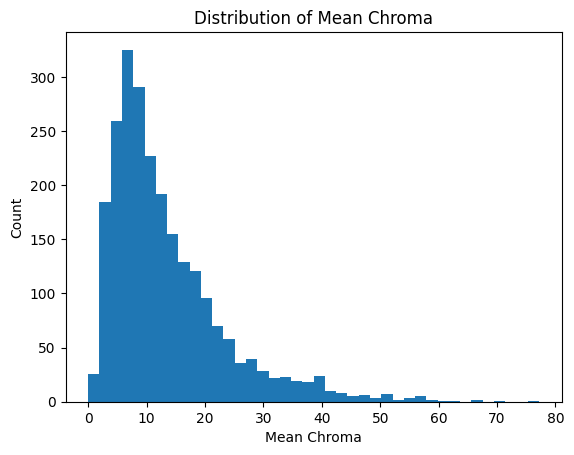

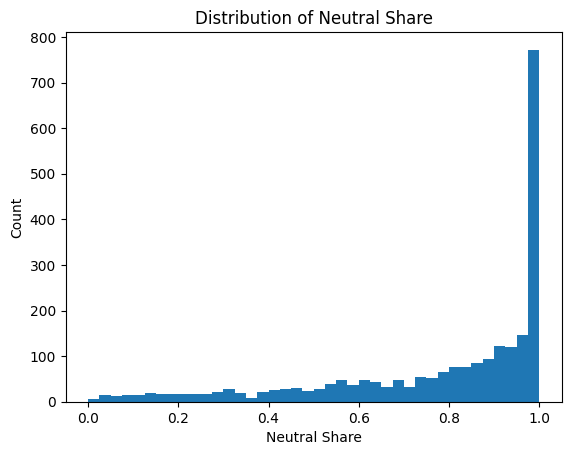

In [10]:
# distribution checks 

plt.figure()
plt.hist(metrics_df["mean_chroma"], bins=40)
plt.xlabel("Mean Chroma")
plt.ylabel("Count")
plt.title("Distribution of Mean Chroma")
plt.show()

plt.figure()
plt.hist(metrics_df["neutral_share"], bins=40)
plt.xlabel("Neutral Share")
plt.ylabel("Count")
plt.title("Distribution of Neutral Share")
plt.show()

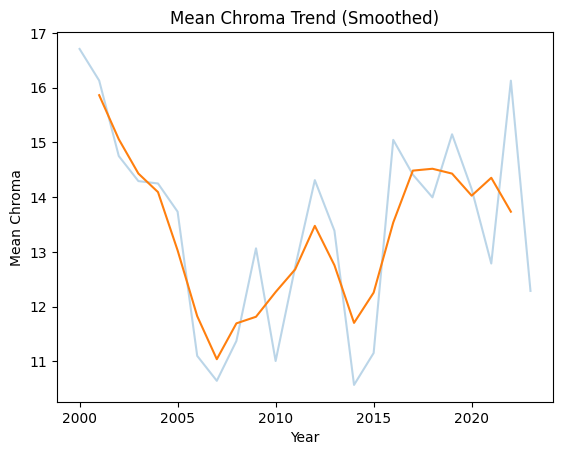

In [11]:
# smooth trend / rolling average to look cool 

yearly["chroma_smooth"] = yearly["mean_chroma"].rolling(3, center=True).mean()
yearly["neutral_smooth"] = yearly["neutral_share"].rolling(3, center=True).mean()

plt.figure()
plt.plot(yearly["year"], yearly["mean_chroma"], alpha=0.3)
plt.plot(yearly["year"], yearly["chroma_smooth"])
plt.xlabel("Year")
plt.ylabel("Mean Chroma")
plt.title("Mean Chroma Trend (Smoothed)")
plt.show()


Now a t-test to check low versus high periods and statistical significance 

In [12]:
from scipy.stats import ttest_ind

# define periods
low_period = metrics_df[metrics_df["year"].between(2006, 2009)]["mean_chroma"]
high_period = metrics_df[metrics_df["year"].between(2017, 2020)]["mean_chroma"]

# check sizes (important)
print("Low n:", len(low_period))
print("High n:", len(high_period))

# Welch’s t-test
t_stat, p_value = ttest_ind(high_period, low_period, equal_var=False)

print("\nLow period mean:", low_period.mean())
print("High period mean:", high_period.mean())
print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: Statistically significant difference ✅")
else:
    print("Result: Not statistically significant ❌")

Low n: 400
High n: 400

Low period mean: 11.54708463639021
High period mean: 14.426324257850647
T-statistic: 3.9091956979893054
P-value: 0.0001006348917175846
Result: Statistically significant difference ✅


Statistically significiant, but the magnitiude of difference might be somethign to explored later. 

In [14]:
low_neutral = metrics_df[metrics_df["year"].between(2006, 2009)]["neutral_share"]
high_neutral = metrics_df[metrics_df["year"].between(2017, 2020)]["neutral_share"]

t_stat_n, p_value_n = ttest_ind(high_neutral, low_neutral, equal_var=False)

print("\nNeutral Share Results")
print("Low mean:", low_neutral.mean())
print("High mean:", high_neutral.mean())
print("P-value:", p_value_n)


Neutral Share Results
Low mean: 0.8287791231134907
High mean: 0.7665141215920448
P-value: 0.00033081794550204944


In [15]:
def get_party(year):
    if 2001 <= year <= 2008:
        return 1   # Republican president
    elif 2009 <= year <= 2016:
        return 0   # Democrat president
    elif 2017 <= year <= 2020:
        return 1
    elif 2021 <= year <= 2023:
        return 0
    else:
        return None

yearly["rep_pres"] = yearly["year"].apply(get_party)

In [17]:
unemp = pd.read_csv("/Users/mariaworkman/fashion/fashion-neutrality/data/UNRATE.csv")
print(unemp.columns)
print(unemp.head())

Index(['observation_date', 'UNRATE'], dtype='str')
  observation_date  UNRATE
0       1948-01-01     3.4
1       1948-02-01     3.8
2       1948-03-01     4.0
3       1948-04-01     3.9
4       1948-05-01     3.5


In [18]:
date_col = None
for col in ["observation_date"]:
    if col in unemp.columns:
        date_col = col
        break

if date_col is None:
    raise ValueError("Could not find a date column in unemployment dataframe.")

unemp["year"] = pd.to_datetime(unemp[date_col]).dt.year

In [19]:
yearly_unemp = (
    unemp
    .groupby("year")
    .agg(unemployment_rate=("UNRATE", "mean"))
    .reset_index()
)

In [20]:
merged = yearly.merge(yearly_unemp, on="year", how="left")
merged = merged.dropna(subset=["mean_chroma", "neutral_share", "rep_pres", "unemployment_rate"])
merged.head()

,year,mean_chroma,neutral_share,count,chroma_smooth,neutral_smooth,rep_pres,unemployment_rate
1,2001,16.130038,0.702347,100,15.863238,0.714535,1.0,4.741667
2,2002,14.751548,0.741918,100,15.058471,0.730447,1.0,5.783333
3,2003,14.293826,0.747077,100,14.431837,0.754475,1.0,5.991667
4,2004,14.250137,0.774431,100,14.093147,0.769759,1.0,5.541667
5,2005,13.735477,0.787768,100,13.029080,0.796564,1.0,5.083333


In [21]:
from sklearn.linear_model import LinearRegression

# features
X = merged[["rep_pres", "unemployment_rate", "year"]]

# target
y = merged["mean_chroma"]

# fit model
model = LinearRegression()
model.fit(X, y)

# predictions
merged["pred_mean_chroma"] = model.predict(X)

# results
print("Intercept:", model.intercept_)
print("Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef}")

print("R^2:", model.score(X, y))

Intercept: -43.824619286669424
Coefficients:
  rep_pres: 0.7117575630892604
  unemployment_rate: -0.12366092097713376
  year: 0.02857875382066048
R^2: 0.08201482245263514


In [22]:
X2 = merged[["rep_pres", "unemployment_rate", "year"]]
y2 = merged["neutral_share"]

model2 = LinearRegression()
model2.fit(X2, y2)

merged["pred_neutral_share"] = model2.predict(X2)

print("Intercept:", model2.intercept_)
print("Coefficients:")
for feature, coef in zip(X2.columns, model2.coef_):
    print(f"  {feature}: {coef}")

print("R^2:", model2.score(X2, y2))

Intercept: 0.854179859649245
Coefficients:
  rep_pres: -0.008592912262457295
  unemployment_rate: 0.00651228752452912
  year: -5.001615145517674e-05
R^2: 0.11356287963572831


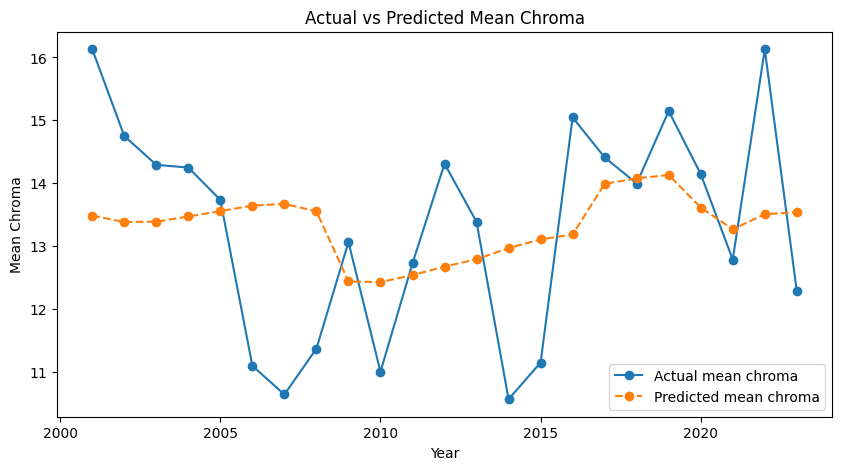

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(merged["year"], merged["mean_chroma"], marker="o", label="Actual mean chroma")
plt.plot(merged["year"], merged["pred_mean_chroma"], marker="o", linestyle="--", label="Predicted mean chroma")
plt.xlabel("Year")
plt.ylabel("Mean Chroma")
plt.title("Actual vs Predicted Mean Chroma")
plt.legend()
plt.show()

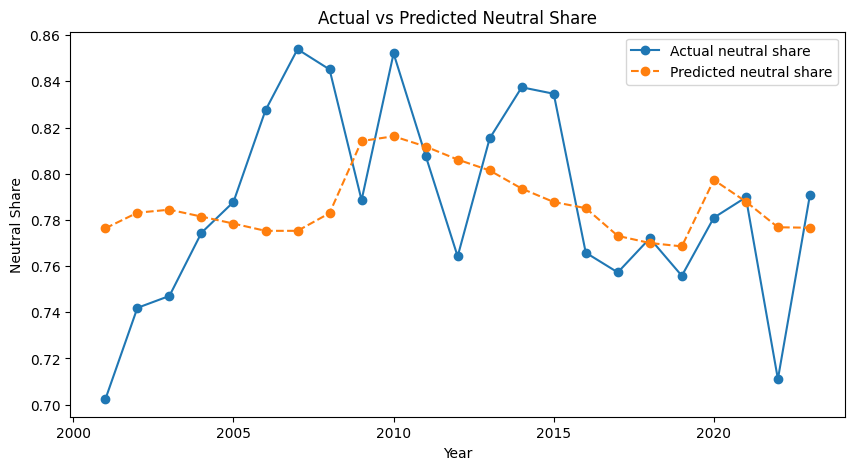

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(merged["year"], merged["neutral_share"], marker="o", label="Actual neutral share")
plt.plot(merged["year"], merged["pred_neutral_share"], marker="o", linestyle="--", label="Predicted neutral share")
plt.xlabel("Year")
plt.ylabel("Neutral Share")
plt.title("Actual vs Predicted Neutral Share")
plt.legend()
plt.show()

In [25]:
from sklearn.linear_model import LinearRegression

# features (ONLY unemployment)
X = merged[["unemployment_rate"]]

# target
y = merged["mean_chroma"]

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficient (unemployment):", model.coef_[0])
print("R^2:", model.score(X, y))

Intercept: 14.617464288187978
Coefficient (unemployment): -0.22126543289402423
R^2: 0.05670477014708519


In [26]:
X = merged[["unemployment_rate", "year"]]
y = merged["mean_chroma"]

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef}")

print("R^2:", model.score(X, y))

Intercept: 16.69464474785196
Coefficients:
unemployment_rate: -0.22207081380814314
year: -0.0010300570663071406
R^2: 0.05672061945958906


In [27]:
X2 = merged[["unemployment_rate", "year"]]
y2 = merged["neutral_share"]

model2 = LinearRegression()
model2.fit(X2, y2)

print("Intercept:", model2.intercept_)
print("Coefficients:")
for feature, coef in zip(X2.columns, model2.coef_):
    print(f"{feature}: {coef}")

print("R^2:", model2.score(X2, y2))

Intercept: 0.12354241650076847
Coefficients:
unemployment_rate: 0.007700371246722939
year: 0.00030744533169803427
R^2: 0.10754362129982364


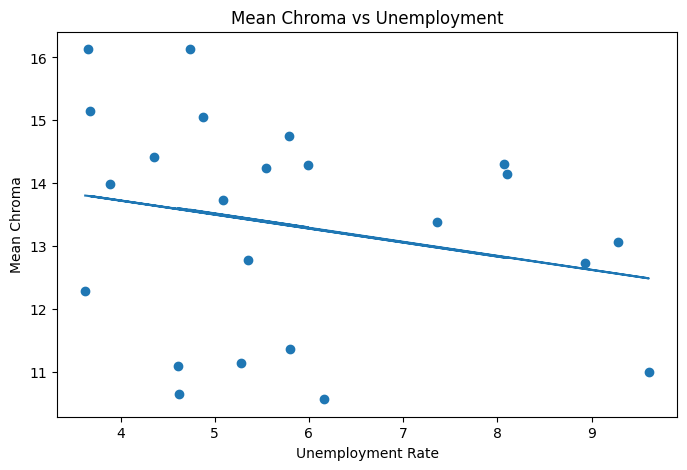

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(merged["unemployment_rate"], merged["mean_chroma"])

# regression line
x_vals = merged["unemployment_rate"]
y_vals = model.predict(X)

plt.plot(x_vals, y_vals)

plt.xlabel("Unemployment Rate")
plt.ylabel("Mean Chroma")
plt.title("Mean Chroma vs Unemployment")
plt.show()

In [29]:
merged["unemp_lag1"] = merged["unemployment_rate"].shift(1)

lag_df = merged.dropna()

X_lag = lag_df[["unemp_lag1", "year"]]
y_lag = lag_df["mean_chroma"]

model_lag = LinearRegression()
model_lag.fit(X_lag, y_lag)

print("Lag model coefficients:", model_lag.coef_)

Lag model coefficients: [-0.25143849  0.06786325]
